In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
gt_data_filtered = np.load("datasets/gt_data_filtered.npy")


# # eg: gt_data_filtered[0, :, get_year(2015)]

# # [ (0, 1) # {0: land temperatures, 1: ocean temperatures}
# #   (0-11) # month of the year
# #   (0-266) # year 1750 - 2015
# #  ]

gt_data_noNaNs = gt_data_filtered[:, :, 100]

def get_year_noNaNs(year: int):
    """
    Converts a year to an index offset from 1850.

    Note: This is for the noNaNs data since the first 100 years have NaNs

    Args:
        year (int): A year between 1850 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1850 → 0, 1851 → 1).
    """
    return year - 1850

gt_data_land_temps = gt_data_filtered[0, :, 3:]

# # eg: gt_data_land_temps[:, get_year_land(1800)] # returns the land average temperatures for every month in the year 1800

# # [ (0-11) # month of the year
# #   (0-263) # year 1753 - 2015
# #  ]

def get_year_land(year: int):
    """
    Converts a year to an index offset from 1753.

    Note: This is for the land temps data since the first 3 years had NaNs for land

    Args:
        year (int): A year between 1753 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1753 → 0, 1754 → 1).
    """
    return year - 1753

In [3]:
# detrend the land temperature using classical/seasonal decomposition

m = 12 # period length

weights = (1/m)*np.ones(m + 1)

weights[0] = 1/2*(1/m)
weights[-1] = 1/2*(1/m)

all_temp_land_data = np.reshape(gt_data_land_temps.T, (gt_data_land_temps.shape[0]*gt_data_land_temps.shape[1]))

T_t = np.convolve(all_temp_land_data, weights, mode='same')[12:-12] # trend with a sliding window of m + 1 (since period is even)

y_t = all_temp_land_data[12:-12] - T_t # detrending to calculate seasonal variation

tot_yrs = 261

month_avg = []

for szn in np.arange(0, 12):
    month_avg.append(np.mean(y_t[szn::12]))

S_t = np.tile(month_avg, tot_yrs) # seasonal variation over time

R_t = all_temp_land_data[12:-12] - T_t - S_t # remainder

In [4]:
# (Celsius * 1.8) + 32

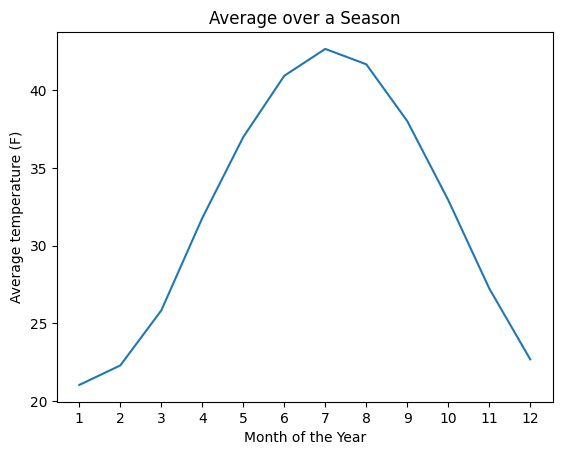

In [5]:
plt.plot(np.arange(1, 13), S_t[:12]*1.8 + 32)
plt.title("Average over a Season")
plt.xticks(np.arange(1, 13))
plt.xlabel("Month of the Year")
plt.ylabel("Average temperature (F)")
plt.show()

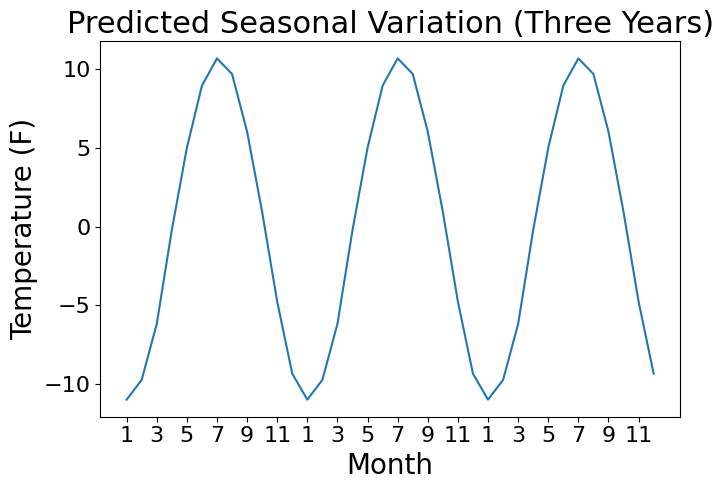

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(np.arange(0, 36), S_t[:36] * 1.8)

ax.set_title("Predicted Seasonal Variation (Three Years)", fontsize=22)
ax.set_xlabel("Month", fontsize=20)
ax.set_ylabel("Temperature (F)", fontsize=20)

ax.set_xticks(np.arange(0, 36, 2))
ax.set_xticklabels(
    np.hstack((
        np.arange(1, 13, 2),
        np.arange(1, 13, 2),
        np.arange(1, 13, 2)
    ))
)

ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()

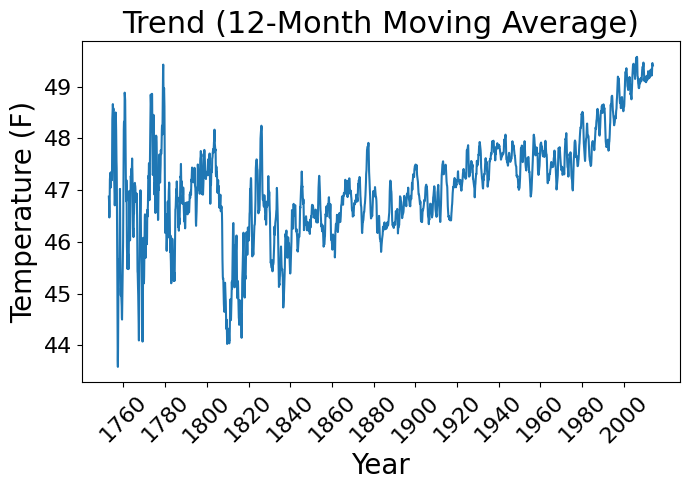

In [7]:
start_year = 1753
interval = 20

year_labels = np.arange(1760, start_year + len(T_t)//12 + 1, interval)
tick_positions = (year_labels - start_year) * 12

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(T_t * 1.8 + 32)

ax.set_title("Trend (12-Month Moving Average)", fontsize=22)
ax.set_xlabel("Year", fontsize=20)
ax.set_ylabel("Temperature (F)", fontsize=20)

ax.set_xticks(tick_positions)
ax.set_xticklabels(year_labels, rotation=45)

ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()

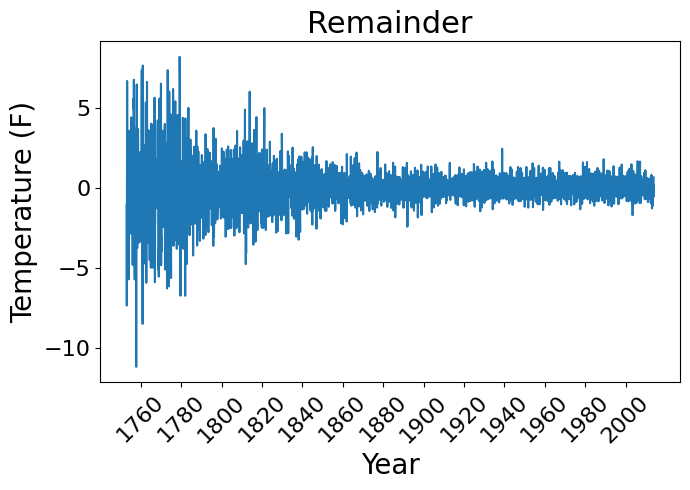

In [8]:
start_year = 1753
interval = 20

year_labels = np.arange(1760, start_year + len(R_t)//12 + 1, interval)
tick_positions = (year_labels - start_year) * 12

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(R_t * 1.8)

ax.set_title("Remainder", fontsize=22)
ax.set_xlabel("Year", fontsize=20)
ax.set_ylabel("Temperature (F)", fontsize=20)

ax.set_xticks(tick_positions)
ax.set_xticklabels(year_labels, rotation=45)

ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()